# Portfolio Simulation Analysis

Use the production simulator to compare allocations and inspect drawdown, benchmark behavior, and scenario outputs.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from simulation.portfolio_simulator import simulate_portfolio

sample_holdings = [
    ("AAPL", 0.25),
    ("MSFT", 0.25),
    ("NVDA", 0.25),
    ("MA", 0.25),
]

result = simulate_portfolio(
    holdings=sample_holdings,
    lookback_years=5,
    rebalance_rule="monthly",
    benchmark="SPY",
    mode="monte_carlo",
    monte_carlo_paths=300,
    horizon_days=252,
)

In [3]:
result["summary"]

{'CAGR': 0.2704579282207664,
 'volatility': 0.2604156788588862,
 'Sharpe_ratio': 1.0385623838237554,
 'max_drawdown': -0.36291924987573565,
 'worst_day': -0.06434428630013911,
 'worst_month': -0.13729653906206563,
 'VaR_95': -0.02547329312579667,
 'CVaR_95': -0.03609479325764506,
 'correlation_with_benchmark': 0.886890972503188,
 'beta_relative_to_benchmark': 1.359889866276754}

In [4]:
result["scenario_results"]

{'ending_value_percentiles': {'p05': 8613.162319557292,
  'p25': 10459.418797114107,
  'p50': 12382.7579621202,
  'p75': 14908.502057543246,
  'p95': 19751.44977022166},
 'max_drawdown_percentiles': {'p05': -0.3486224782653485,
  'p25': -0.23936670008996475,
  'p50': -0.18943463369546615,
  'p75': -0.14297648014561046,
  'p95': -0.0988670390195865},
 'probability_of_loss': 0.18}

In [5]:
import pandas as pd

ts = pd.DataFrame(
    {
        "Date": pd.to_datetime(result["timeseries"]["dates"]),
        "PortfolioValue": result["timeseries"]["portfolio_value"],
        "Drawdown": result["timeseries"]["drawdown"],
    }
).set_index("Date")
ts.head()

,PortfolioValue,Drawdown
Date,,
2021-03-22,10211.571297,0.000000
2021-03-23,10166.689910,-0.004395
2021-03-24,10040.102604,-0.016792
2021-03-25,9986.642382,-0.022027
2021-03-26,10158.212203,-0.005225


Text(0, 0.5, 'Value')

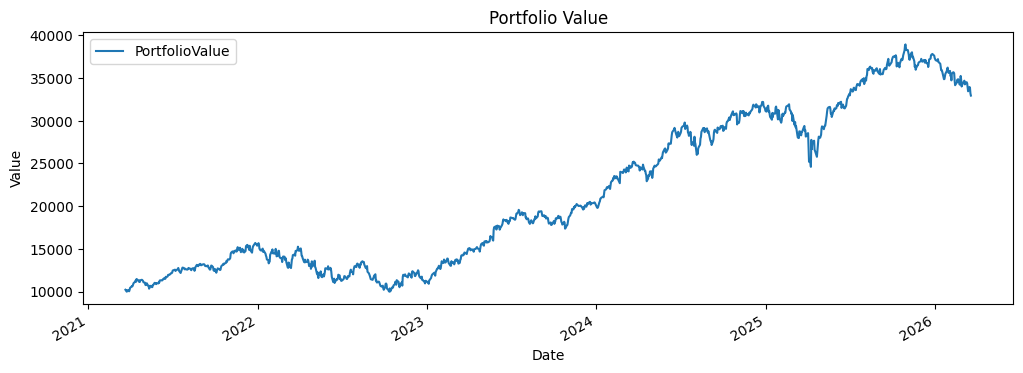

In [6]:
ax = ts[["PortfolioValue"]].plot(figsize=(12, 4), title="Portfolio Value")
ax.set_ylabel("Value")

Text(0, 0.5, 'Drawdown')

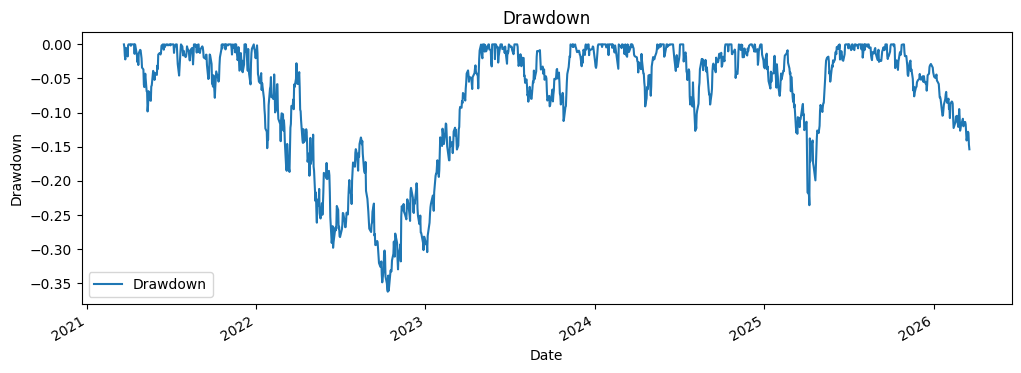

In [7]:
ax = ts[["Drawdown"]].plot(figsize=(12, 4), title="Drawdown")
ax.set_ylabel("Drawdown")